### Face Emotion Recognition 

##### Import the dependecies

In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
from deepface import DeepFace

26-09-21 14:12:35 - ⚠️ 
 ⚠️ DEPRECATION WARNING:
 Running 'pip install deepface' alone will no longer be sufficient and will
 NOT install a default backend in an upcoming major release.

 Currently, TensorFlow is included by default, but this behavior will be deprecated.
 Please explicitly specify your preferred backend engine when installing:

   -> pip install deepface[tensorflow]
   -> pip install deepface[pytorch]

 Otherwise, you will encounter 'module not found' errors.




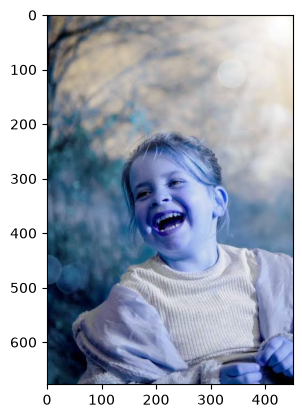

In [2]:
img = cv.imread('Images/happy.jpg')
plt.imshow(img)

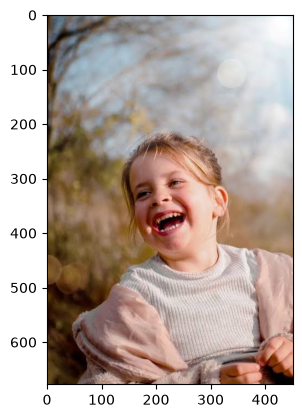

In [3]:
img = cv.imread('Images/happy.jpg')
if img is None:
    raise FileNotFoundError("Could not read image: Images/happy.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img)

In [4]:
predictions = DeepFace.analyze(img, actions=["emotion"],detector_backend="retinaface")

In [5]:
predictions

[{'emotion': {'angry': np.float32(1.9363449e-07),
   'disgust': np.float32(6.714113e-23),
   'fear': np.float32(1.1330768e-10),
   'happy': np.float32(100.0),
   'sad': np.float32(8.9162115e-11),
   'surprise': np.float32(6.260535e-15),
   'neutral': np.float32(2.2316944e-13)},
  'dominant_emotion': 'happy',
  'region': {'x': 152,
   'y': 251,
   'w': 149,
   'h': 194,
   'left_eye': (237, 305),
   'right_eye': (174, 330),
   'nose': (203, 333),
   'mouth_left': (254, 371),
   'mouth_right': (193, 392)},
  'face_confidence': 1.0}]

#### read images and change to RGB format

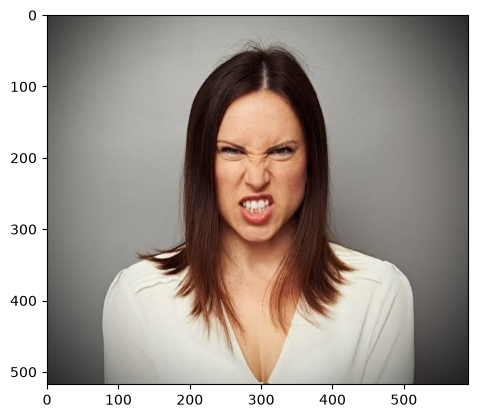

In [6]:
img2 = cv.imread("Images/angry.jpg")
plt.imshow(cv.cvtColor(img2,cv.COLOR_BGR2RGB))

#### Detection:

In [7]:
predictions2= DeepFace.analyze(img2,actions=["emotion"])

In [8]:
predictions2

[{'emotion': {'angry': np.float32(62.027523),
   'disgust': np.float32(37.897507),
   'fear': np.float32(0.00593644),
   'happy': np.float32(7.7544044e-08),
   'sad': np.float32(0.0014593131),
   'surprise': np.float32(0.06753934),
   'neutral': np.float32(3.25313e-05)},
  'dominant_emotion': 'angry',
  'region': {'x': 209,
   'y': 125,
   'w': 173,
   'h': 173,
   'left_eye': None,
   'right_eye': None},
  'face_confidence': 0.92}]

### Face Detection + Drawing rectangle

##### draw rectangle and put the text of the image emotions

In [9]:
# to detect the objects
face_cascades = cv.CascadeClassifier('Images/haarcascade_frontalface_default.xml') 
# convert to gry scale 
gray = cv.cvtColor(img2,cv.COLOR_BGR2GRAY)
# multi object dections
faces = face_cascades.detectMultiScale(gray,1.1,4)
# draw the rectangle of each detected objects
for(x,y,w,h) in faces:
    cv.rectangle(img2,(x,y),(x+w,y+h),(0,255,0),2)




#### Now see the rectangle box detect the face 

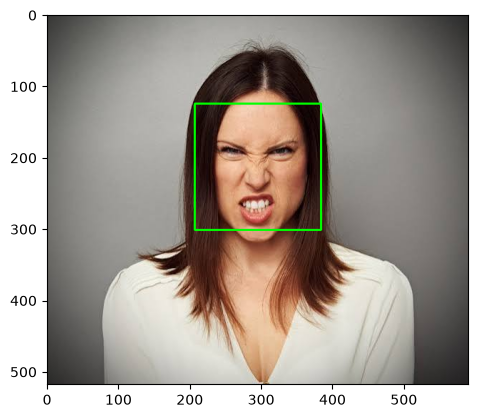

In [10]:
plt.imshow(cv.cvtColor(img2,cv.COLOR_BGR2RGB))

In [11]:
img = cv.imread('Images/happy.jpg')
img1 = img.copy()
face_cascades = cv.CascadeClassifier('Images/haarcascade_frontalface_default.xml')
gray = cv.cvtColor(img1,cv.COLOR_BGR2GRAY)
faces = face_cascades.detectMultiScale(gray,1.1,4)
for x,y,w,h in faces:
    cv.rectangle(img1,(x,y),(x+w,y+h),(0,255,0),2)


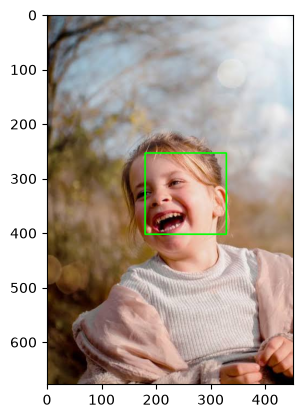

In [12]:
plt.imshow(cv.cvtColor(img1,cv.COLOR_BGR2RGB))

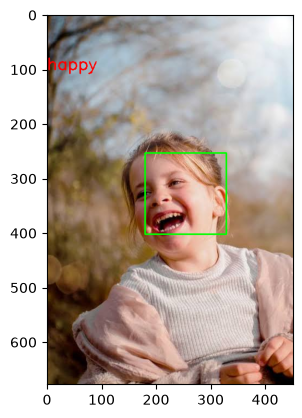

In [13]:
img_out = img1.copy()
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(img_out,
           predictions[0]['dominant_emotion'],
           (0,100),
           font,
           1,
           (0,0,255),
           2,
           cv.LINE_4)
plt.imshow(cv.cvtColor(img_out,cv.COLOR_BGR2RGB))

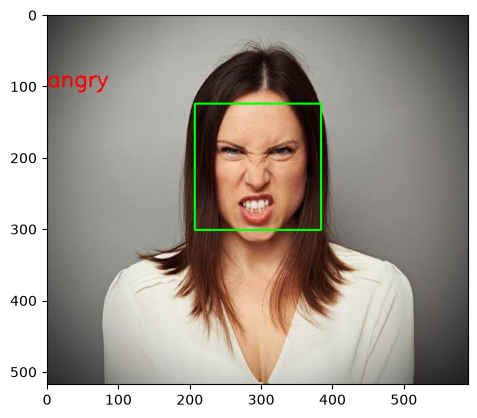

In [15]:
img2_out = img2.copy()
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(img2_out,
           predictions2[0]['dominant_emotion'],
           (0,100),
           font,
           1,
           (0,0,255),
           2,
           cv.LINE_4)
plt.imshow(cv.cvtColor(img2_out,cv.COLOR_BGR2RGB))
